# 05 — `solve_receding_horizon` test suite

A structured exploration of the **receding-horizon MILP** that powers AeroGrid's scheduling core.  
Each scenario isolates one aspect of the formulation — from price-valley shifting through
power-cap coupling to comfort-deadline forcing.

| # | Scenario | Feature under test |
|---|---|---|
| A | Price-aware valley shifting | Cheapest slots absorb EV + appliances |
| B | EV deadline inside / outside horizon | Constraint C2 regime switch |
| C | Power-cap binding | EV ↔ appliance coupling (C6) |
| D | Committed task as exogenous load | Pinned cycles consume cap headroom |
| E | Heater comfort-deadline forcing | C5 overrides price signal |
| F | 24 h receding-horizon sweep | Rolling replanning accumulates daily savings |
| G | Ghost-reservation λ sensitivity | Balancing cost vs. user intent |


In [1]:
import sys, warnings
from pathlib import Path
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    from IPython.display import display
except ImportError:
    display = print  # plain-script fallback

from aerogrid.optimizer import solve_receding_horizon
from aerogrid.config import APPLIANCES, SLOT_MINUTES, HOUSE_POWER_CAP_KW
from aerogrid.types import ScheduledTask

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# ── constants ────────────────────────────────────────────────────────────────
SLOT_H = SLOT_MINUTES / 60          # 0.25 h per slot
_PER_SLOT = SLOT_H / 1000.0         # kW·(€/MWh) → € per slot

_PALETTE = {
    "ev_charger":      "#ff7f0e",
    "dishwasher":      "#1f77b4",
    "washing_machine": "#2ca02c",
    "heater":          "#d62728",
}


def _utc(h: int, m: int = 0) -> datetime:
    return datetime(2026, 4, 3, h, m, tzinfo=timezone.utc)


# ── shared plotting helper ────────────────────────────────────────────────────
def plot_schedule(sched, prices, *, title="", cap_kw=HOUSE_POWER_CAP_KW, figsize=(12, 5)):
    """Stacked-bar load chart (top) + price step chart (bottom)."""
    T   = sched.horizon_slots
    hrs = np.arange(T) * SLOT_H
    prices = np.asarray(prices, dtype=float)

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 2]},
    )
    bottom = np.zeros(T)

    # EV bar
    ev = np.asarray(sched.ev_power_kw, dtype=float)
    ax1.bar(hrs, ev, width=SLOT_H * 0.85, bottom=bottom,
            color=_PALETTE["ev_charger"], alpha=0.85, label="EV charger", align="edge")
    bottom = bottom + ev

    # Cycle tasks (stack each running-indicator on top)
    seen: set = set()
    for task in sched.tasks:
        app  = task.appliance
        spec = APPLIANCES.get(app)
        if spec is None:
            continue
        run = np.zeros(T)
        for t in range(task.start_slot, min(task.start_slot + task.slots, T)):
            run[t] = spec.rated_kw
        color  = _PALETTE.get(app, "#8c564b")
        hatch  = "//" if task.committed else None
        label  = (app + (" [committed]" if task.committed else "")) if app not in seen else None
        ax1.bar(hrs, run, width=SLOT_H * 0.85, bottom=bottom,
                color=color, alpha=0.7, label=label, hatch=hatch, align="edge")
        bottom = bottom + run
        seen.add(app)

    # Power-cap line
    ax1.axhline(cap_kw, color="red", ls="--", lw=1.5, label=f"Cap {cap_kw} kW")
    ax1.set_ylabel("load (kW)")
    ax1.set_ylim(0, cap_kw * 1.3)
    ax1.legend(loc="upper right", fontsize=8)
    ax1.set_title(title or "Optimizer schedule", fontsize=11)

    ann = (f"Cost: €{sched.expected_cost:.4f}  ·  "
           f"Baseline: €{sched.baseline_cost:.4f}  ·  "
           f"Savings: {sched.savings()*100:.1f}%  ·  "
           f"Status: {sched.solver_status}")
    ax1.text(0.01, 0.98, ann, transform=ax1.transAxes, va="top", fontsize=7.5,
             bbox=dict(boxstyle="round,pad=0.25", fc="lightyellow", ec="#cca300", alpha=0.9))

    # Price area
    ax2.step(hrs, prices[:T], where="post", color="k", lw=1.5, label="Price (€/MWh)")
    ax2.fill_between(hrs, prices[:T], step="post", alpha=0.12, color="k")
    ax2.set_ylabel("€/MWh")
    ax2.set_xlabel(f"hour from now  (slot = {SLOT_MINUTES} min)")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    return fig


# ── per-slot breakdown table ──────────────────────────────────────────────────
def summary_df(sched, prices) -> pd.DataFrame:
    T   = sched.horizon_slots
    ev  = np.asarray(sched.ev_power_kw, dtype=float)
    rows = []
    for t in range(T):
        cycle_kw, apps = 0.0, []
        for task in sched.tasks:
            if task.start_slot <= t < task.start_slot + task.slots:
                cycle_kw += APPLIANCES[task.appliance].rated_kw
                apps.append(task.appliance + ("*" if task.committed else ""))
        total    = ev[t] + cycle_kw
        slot_eur = total * float(prices[t]) * _PER_SLOT
        rows.append({
            "slot": t,
            "h": f"{t*SLOT_H:.2f}",
            "€/MWh": round(float(prices[t]), 1),
            "EV kW":    round(float(ev[t]), 2),
            "cycle kW": round(cycle_kw, 2),
            "total kW": round(total, 2),
            "slot €":   round(slot_eur, 5),
            "running":  ", ".join(apps) or "—",
        })
    df = pd.DataFrame(rows).set_index("slot")
    total_row = df[["EV kW", "cycle kW", "total kW", "slot €"]].sum()
    df.loc["∑"] = total_row
    return df


print("✓ helpers loaded  (SLOT_H=0.25 h, cap=", HOUSE_POWER_CAP_KW, "kW)")


✓ helpers loaded  (SLOT_H=0.25 h, cap= 10.0 kW)


## Scenario A — Price-aware valley shifting

A **16-slot (4 h)** horizon exposes a clear cheap valley at slots 6–10 (hours 1.5–2.5).  
The optimizer should defer EV charging **and** both appliance cycles into that window.

| slot  | 0–5 | 6 | 7 | 8 | 9 | 10 | 11–15 |
|-------|-----|---|---|---|---|----|-------|
| €/MWh | 110–90 | 55 | 35 | 28 | 30 | 38 | 75–115 |

Setup: EV needs 6 kWh, deadline 20 h away, washing machine + heater predicted.  
Washing machine (6 slots): latest start = slot 10. Heater (4 slots): latest start = slot 12.  
**Expected**: both cycles and the bulk of EV charging land in the valley.


,h,€/MWh,EV kW,cycle kW,total kW,slot €,running
slot,,,,,,,
0,0.00,110.0,0.00,0.0,0.00,0.0000,—
1,0.25,100.0,0.00,0.0,0.00,0.0000,—
2,0.50,95.0,0.00,0.0,0.00,0.0000,—
3,0.75,90.0,0.00,0.0,0.00,0.0000,—
4,1.00,75.0,0.00,0.0,0.00,0.0000,—
5,1.25,60.0,0.00,0.0,0.00,0.0000,—
6,1.50,55.0,0.00,0.0,0.00,0.0000,—
7,1.75,35.0,0.00,2.4,2.40,0.0210,washing_machine
8,2.00,28.0,5.49,4.4,9.89,0.0692,"washing_machine, heater"


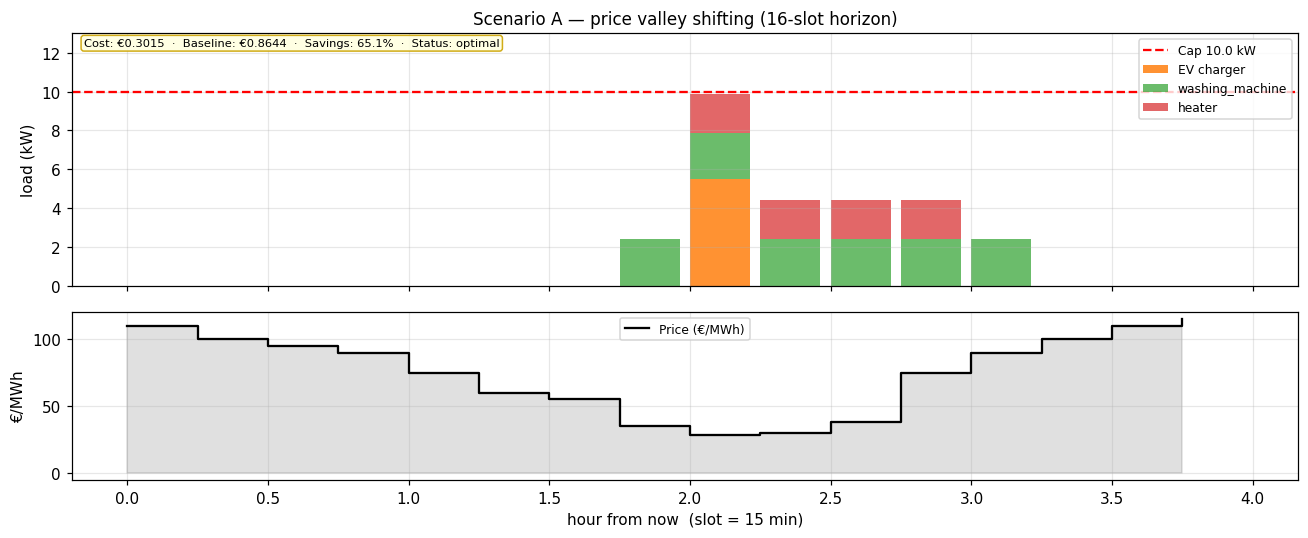

In [11]:
T_A       = 16
prices_A  = np.array([110., 100., 95., 90., 75., 60., 55., 35., 28., 30., 38., 75., 90., 100., 110., 115.])
now_A     = _utc(10)   # 10:00 UTC → next 07:00 deadline is 21 h away

# Onset peaks at the centre of the cheap valley (slot 7–8)
_g = lambda mu, s: np.exp(-0.5*((np.arange(T_A)-mu)/s)**2)
onset_A = {
    "washing_machine": (_g(7.5, 2.0) + 0.02).clip(0, 1),
    "heater":          (_g(8.0, 1.5) + 0.02).clip(0, 1),
}

sched_A = solve_receding_horizon(
    now_A, prices_A, onset_A,
    remaining_ev_kwh=6.0,
    horizon_slots=T_A,
)
display(summary_df(sched_A, prices_A))
fig_A = plot_schedule(sched_A, prices_A, title="Scenario A — price valley shifting (16-slot horizon)")
plt.show()


## Scenario B — EV deadline inside vs. outside the horizon

Same price profile (cheap valley in slots 2–4, expensive bookends); two deadline distances:

* **B-near**: deadline **1 h 15 min** away (5 slots) — the full EV need must arrive by slot 5.  
* **B-far**:  deadline **20 h** away — optimizer is free to shift into the valley.

Constraint C2 switches between the two integration regimes:  
`Δt · Σ_{t<t_d} p_ev[t] + σ_ev ≥ remaining_ev_kwh`  vs.  the prorated version.


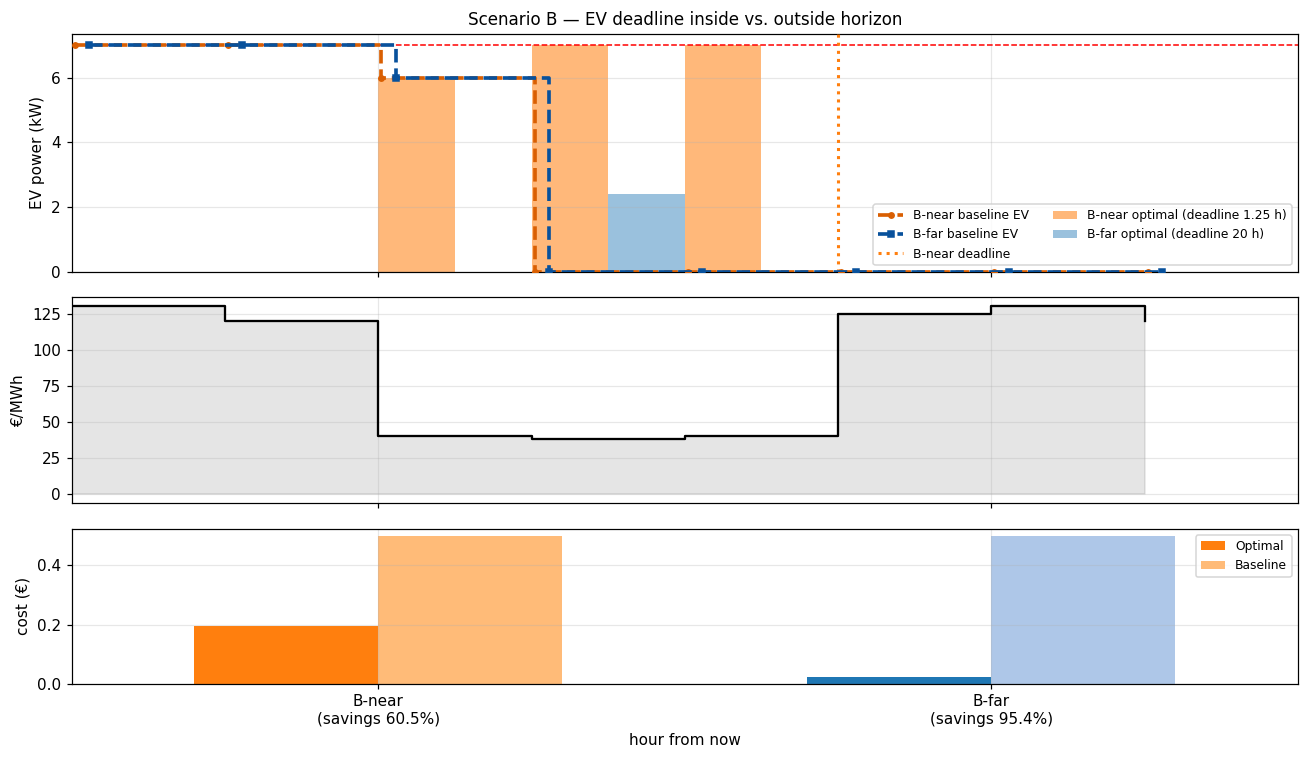

B-near: €0.1965  B-far: €0.0228  Δ = €0.1737


In [15]:
prices_B = np.array([130., 120., 40., 38., 40., 125., 130., 120.])
onset_B  = {}    # no appliances — isolate pure EV behaviour

sched_B_near = solve_receding_horizon(
    _utc(5, 45), prices_B, onset_B,
    remaining_ev_kwh=5.0,
    time_to_deadline_h=1.25,    # ← inside the 2h horizon
    horizon_slots=8,
)
sched_B_far = solve_receding_horizon(
    _utc(10, 0), prices_B, onset_B,
    remaining_ev_kwh=5.0,
    time_to_deadline_h=20.0,    # ← well outside the horizon
    horizon_slots=8,
)

def _baseline_ev_profile(ev_need_kwh, horizon_slots, rated_kw, slot_h):
    p = np.zeros(horizon_slots, dtype=float)
    remaining = float(ev_need_kwh)
    for t in range(horizon_slots):
        if remaining <= 0:
            break
        add = min(rated_kw, remaining / slot_h)
        p[t] = add
        remaining -= add * slot_h
    return p

hrs = np.arange(8) * SLOT_H
fig_B, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True,
                            gridspec_kw={"height_ratios": [2.3, 2, 1.5]})

base_ev_near = _baseline_ev_profile(5.0, 8, APPLIANCES["ev_charger"].rated_kw, SLOT_H)
base_ev_far = _baseline_ev_profile(5.0, 8, APPLIANCES["ev_charger"].rated_kw, SLOT_H)

# EV power comparison (optimized bars + clearly visible baseline overlays)
axes[0].bar(hrs,            sched_B_near.ev_power_kw, width=SLOT_H*0.5,
            color="#ff7f0e", alpha=0.55, label="B-near optimal (deadline 1.25 h)",
            align="edge", zorder=1)
axes[0].bar(hrs+SLOT_H*0.5, sched_B_far.ev_power_kw, width=SLOT_H*0.5,
            color="#1f77b4", alpha=0.45, label="B-far optimal (deadline 20 h)",
            align="edge", zorder=1)
axes[0].step(hrs + SLOT_H*0.02, base_ev_near, where="post", color="#d95f02", ls="--", lw=2.4,
             marker="o", markersize=3.5, label="B-near baseline EV", zorder=4)
axes[0].step(hrs + SLOT_H*0.11375, base_ev_far, where="post", color="#08519c", ls="--", lw=2.4,
             marker="s", markersize=3.3, label="B-far baseline EV", zorder=4)
axes[0].axvline(1.25, color="#ff7f0e", ls=":", lw=2, label="B-near deadline", zorder=3)
axes[0].axhline(APPLIANCES["ev_charger"].rated_kw, color="red", ls="--", lw=1, zorder=2)
axes[0].set_ylabel("EV power (kW)")
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_title("Scenario B — EV deadline inside vs. outside horizon", fontsize=11)

# Price
axes[1].step(hrs, prices_B, where="post", color="k", lw=1.5)
axes[1].fill_between(hrs, prices_B, step="post", alpha=0.1, color="k")
axes[1].set_ylabel("€/MWh")

# Cost comparison bar chart
labels = ["B-near", "B-far"]
opt_costs = [sched_B_near.expected_cost, sched_B_far.expected_cost]
bas_costs = [sched_B_near.baseline_cost, sched_B_far.baseline_cost]
savings   = [sched_B_near.savings()*100, sched_B_far.savings()*100]
x = np.array([0.5, 1.5])
w = 0.3
axes[2].bar(x - w/2, opt_costs, w, color=["#ff7f0e","#1f77b4"], label="Optimal")
axes[2].bar(x + w/2, bas_costs, w, color=["#ffbb78","#aec7e8"], label="Baseline")
axes[2].set_xticks(x)
axes[2].set_xticklabels([f"{l}\n(savings {s:.1f}%)" for l, s in zip(labels, savings)])
axes[2].set_ylabel("cost (€)")
axes[2].legend(fontsize=8)
axes[2].set_xlim(0, 2)
axes[2].set_xlabel("hour from now")

plt.tight_layout()
plt.show()
print(f"B-near: €{sched_B_near.expected_cost:.4f}  "
      f"B-far: €{sched_B_far.expected_cost:.4f}  "
      f"Δ = €{sched_B_near.expected_cost - sched_B_far.expected_cost:.4f}")


## Scenario C — Power-cap binding (EV ↔ appliance coupling)

EV rated at 7 kW + dishwasher at 2.5 kW = **9.5 kW**.

* **C-tight**: cap = 9 kW → the MILP must throttle EV to `9 − 2.5 = 6.5 kW` while the dishwasher runs.  
* **C-loose**: cap = 10 kW (default) → EV can run at full 7 kW alongside the dishwasher.

The house-cap constraint (C6) is the **only** link between EV and cycle variables.  
Price profile is cheapest early (slots 0–3), so the dishwasher starts at slot 0 in both cases;  
the difference is how much EV power the cap allows during the overlap.


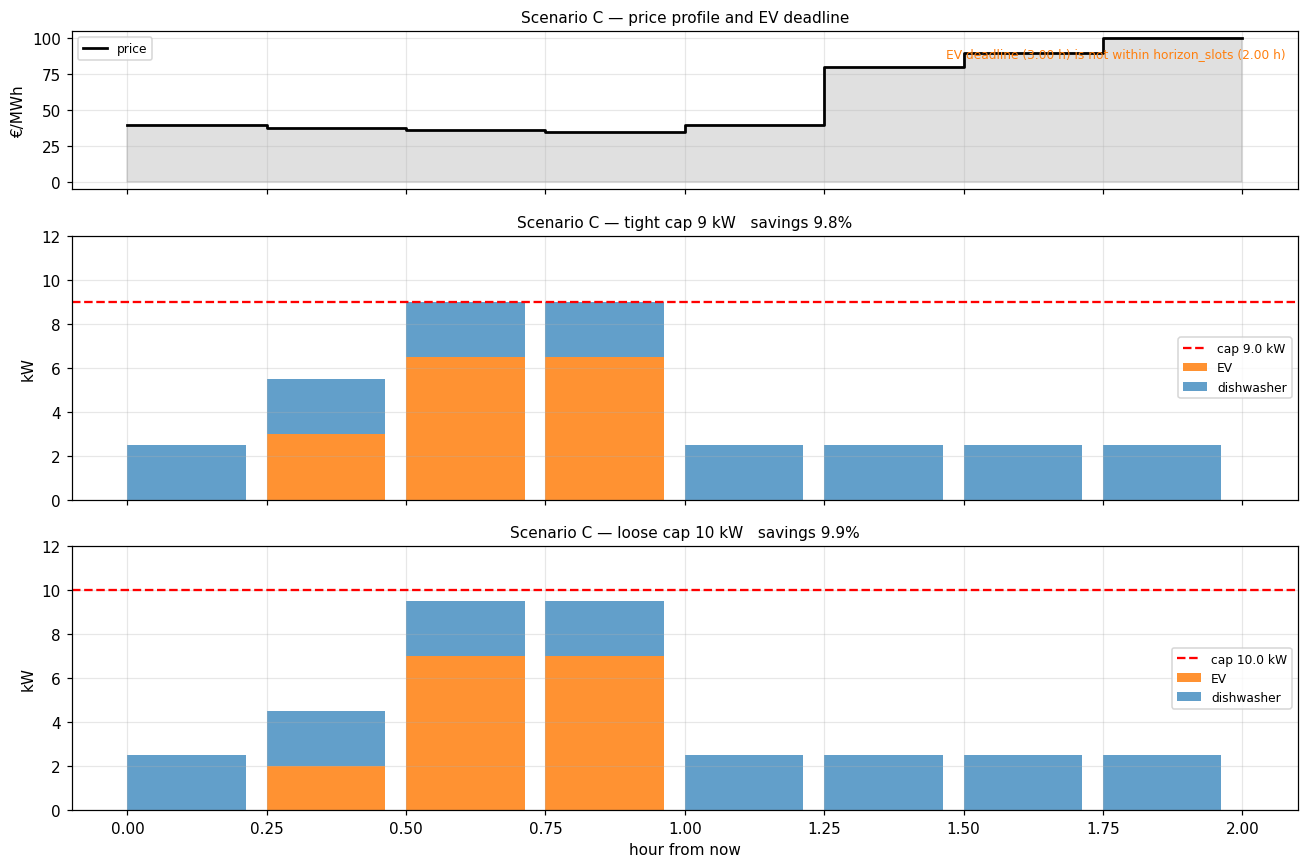

Tight EV : ['0.00', '3.00', '6.50', '6.50', '0.00', '0.00', '0.00', '0.00']
Loose EV : ['0.00', '2.00', '7.00', '7.00', '0.00', '0.00', '0.00', '0.00']
  tight: dishwasher starts slot 0
  loose: dishwasher starts slot 0


In [20]:
prices_C = np.array([40., 38., 36., 35., 40., 80., 90., 100.])
onset_C  = {"dishwasher": np.array([0.8, 0.7, 0.5, 0.3, 0.1, 0.05, 0.05, 0.0])}
now_C    = _utc(4)      # 04:00 UTC, deadline ~3 h away

kwargs_C = dict(remaining_ev_kwh=5.0, time_to_deadline_h=3.0, horizon_slots=8)

sched_C_tight = solve_receding_horizon(now_C, prices_C, onset_C, house_cap_kw=9.0,  **kwargs_C)
sched_C_loose = solve_receding_horizon(now_C, prices_C, onset_C, house_cap_kw=10.0, **kwargs_C)

fig_C, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                           gridspec_kw={"height_ratios": [1.2, 2, 2]})
hrs = np.arange(8) * SLOT_H
hrs_edges = np.arange(9) * SLOT_H
prices_C_step = np.r_[prices_C, prices_C[-1]]
deadline_h = kwargs_C["time_to_deadline_h"]
horizon_h = kwargs_C["horizon_slots"] * SLOT_H
deadline_in_horizon = deadline_h <= horizon_h

# Price + deadline reference
axes[0].step(hrs_edges, prices_C_step, where="post", color="black", lw=1.8, label="price")
axes[0].fill_between(hrs_edges, prices_C_step, step="post", alpha=0.12, color="black")
if deadline_in_horizon:
    axes[0].axvline(deadline_h, color="#ff7f0e", ls=":", lw=2, label=f"EV deadline ({deadline_h:.2f} h)")
else:
    axes[0].text(
        0.99,
        0.9,
        f"EV deadline ({deadline_h:.2f} h) is not within horizon_slots ({horizon_h:.2f} h)",
        ha="right",
        va="top",
        transform=axes[0].transAxes,
        fontsize=8,
        color="#ff7f0e",
    )
axes[0].set_ylabel("€/MWh")
axes[0].legend(fontsize=8)
axes[0].set_title("Scenario C — price profile and EV deadline", fontsize=10)

for ax, sched, cap, label in [
    (axes[1], sched_C_tight, 9.0,  "tight cap 9 kW"),
    (axes[2], sched_C_loose, 10.0, "loose cap 10 kW"),
]:
    ev = np.asarray(sched.ev_power_kw, dtype=float)
    dw = np.zeros(8)
    for task in sched.tasks:
        if task.appliance == "dishwasher":
            for t in range(task.start_slot, min(task.start_slot + task.slots, 8)):
                dw[t] = APPLIANCES["dishwasher"].rated_kw
    ax.bar(hrs, ev, width=SLOT_H*0.85, color=_PALETTE["ev_charger"],   alpha=0.85, label="EV",         align="edge")
    ax.bar(hrs, dw, width=SLOT_H*0.85, bottom=ev, color=_PALETTE["dishwasher"], alpha=0.7,  label="dishwasher", align="edge")
    ax.axhline(cap, color="red", ls="--", lw=1.5, label=f"cap {cap} kW")
    if deadline_in_horizon:
        ax.axvline(deadline_h, color="#ff7f0e", ls=":", lw=2)
    ax.set_ylim(0, 12)
    ax.set_ylabel("kW")
    ax.legend(fontsize=8)
    ax.set_title(f"Scenario C — {label}   savings {sched.savings()*100:.1f}%", fontsize=10)

axes[2].set_xlabel("hour from now")
plt.tight_layout()
plt.show()

print("Tight EV :", [f"{v:.2f}" for v in sched_C_tight.ev_power_kw])
print("Loose EV :", [f"{v:.2f}" for v in sched_C_loose.ev_power_kw])
for s, lbl in [(sched_C_tight, "tight"), (sched_C_loose, "loose")]:
    for t in s.tasks:
        print(f"  {lbl}: {t.appliance} starts slot {t.start_slot}")


## Scenario D — Committed task as exogenous load

A **washing machine** is already committed and occupies slots 2–7 (6 × 15 min = 1.5 h, 2.4 kW).  
With `house_cap_kw = 8.5 kW` the EV has only **6.1 kW** of headroom during the overlap  
(8.5 − 2.4 = 6.1 < 7.0 kW charger max), so the MILP **must throttle** the EV there.

Committed tasks appear with a hatch pattern in the Gantt.


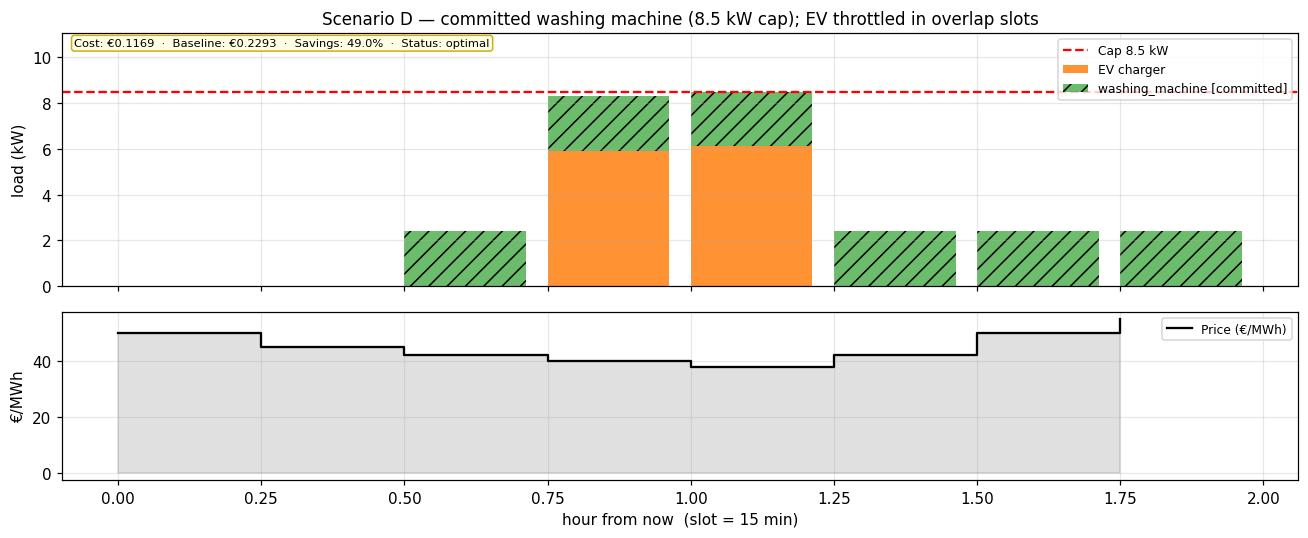

,h,€/MWh,EV kW,cycle kW,total kW,slot €,running
slot,,,,,,,
0,0.00,50.0,0.0,0.0,0.0,0.00000,—
1,0.25,45.0,0.0,0.0,0.0,0.00000,—
2,0.50,42.0,0.0,2.4,2.4,0.02520,washing_machine*
3,0.75,40.0,5.9,2.4,8.3,0.08300,washing_machine*
4,1.00,38.0,6.1,2.4,8.5,0.08075,washing_machine*
5,1.25,42.0,0.0,2.4,2.4,0.02520,washing_machine*
6,1.50,50.0,0.0,2.4,2.4,0.03000,washing_machine*
7,1.75,55.0,0.0,2.4,2.4,0.03300,washing_machine*
∑,NaN,NaN,12.0,14.4,26.4,0.27715,NaN



Max total load: 8.5 kW  (cap = 8.5 kW)
Cap constraint satisfied ✓


In [ ]:
prices_D = np.array([50., 45., 42., 40., 38., 42., 50., 55.])
now_D    = _utc(3)

committed_D = [
    ScheduledTask(
        appliance="washing_machine",
        start_slot=2,
        slots=APPLIANCES["washing_machine"].cycle_slots,          # 6 slots
        expected_kwh=APPLIANCES["washing_machine"].rated_kw * 6 * SLOT_H,
        committed=True,
    )
]

sched_D = solve_receding_horizon(
    now_D, prices_D, onset_probs={},
    remaining_ev_kwh=5.0,
    time_to_deadline_h=4.0,
    committed_tasks=committed_D,
    horizon_slots=8,
    house_cap_kw=8.5,
)

fig_D = plot_schedule(
    sched_D, prices_D,
    title="Scenario D — committed washing machine (8.5 kW cap); EV throttled in overlap slots",
    cap_kw=8.5,
)
plt.show()
display(summary_df(sched_D, prices_D))

# Sanity: confirm no slot exceeds the cap
ev  = np.asarray(sched_D.ev_power_kw, dtype=float)
wm_kw = APPLIANCES["washing_machine"].rated_kw
wm_load = np.zeros(8)
for t in range(2, 8):
    wm_load[t] = wm_kw
total_load = ev + wm_load
print("\nMax total load:", total_load.max().round(3), "kW  (cap = 8.5 kW)")
assert total_load.max() <= 8.5 + 1e-4, "Cap violated!"
print("Cap constraint satisfied ✓")


## Scenario E — Heater comfort-deadline forcing

The **heater** needs 4 slots (1 h) and must **finish by 07:00 UTC** (C5).  
`now` = 06:15 UTC → only 45 min = 3 slots remain to the deadline.

Since `latest_start = deadline_slot − L = 3 − 4 = −1 ≤ 0`, the C5 branch
`s[1:] = 0` fires: the cycle **can only start at slot 0**.

Slot-0 price is set to **€250/MWh** — far above the rest of the horizon —  
to prove the optimizer accepts the penalty rather than missing the deadline.


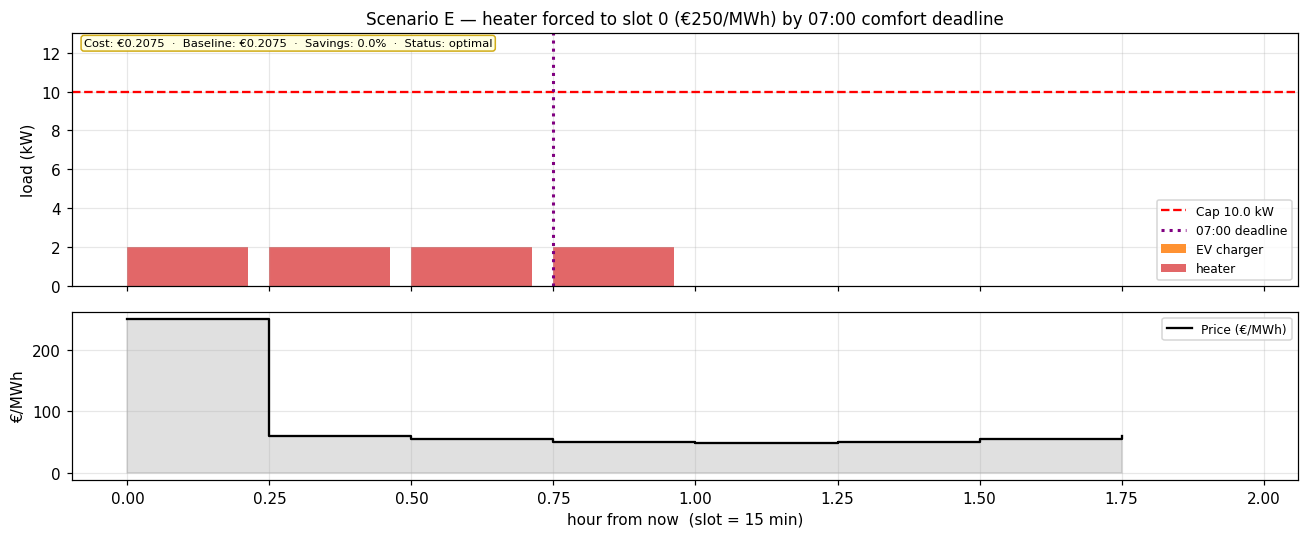

Heater: start_slot=0  (0.00h – 1.00h from now)
Start slot 0 forced by C5 deadline constraint ✓


In [22]:
# 06:15 UTC — 45 min to the 07:00 deadline
prices_E = np.array([250., 60., 55., 50., 48., 50., 55., 60.])
now_E    = _utc(6, 15)

onset_E = {
    "heater": np.array([0.9, 0.5, 0.2, 0.1, 0.05, 0.05, 0.02, 0.01]),
}

sched_E = solve_receding_horizon(
    now_E, prices_E, onset_E,
    remaining_ev_kwh=0.0,       # EV not connected — isolate heater behaviour
    horizon_slots=8,
    house_cap_kw=10.0,
)

fig_E = plot_schedule(
    sched_E, prices_E,
    title="Scenario E — heater forced to slot 0 (€250/MWh) by 07:00 comfort deadline",
    cap_kw=10.0,
)
# add deadline marker
fig_E.axes[0].axvline(0.75, color="purple", ls=":", lw=2, label="07:00 deadline")
fig_E.axes[0].legend(fontsize=8)
plt.show()

heater_tasks = [t for t in sched_E.tasks if t.appliance == "heater"]
if heater_tasks:
    ht = heater_tasks[0]
    print(f"Heater: start_slot={ht.start_slot}  "
          f"({ht.start_slot*0.25:.2f}h – {(ht.start_slot+ht.slots)*0.25:.2f}h from now)")
    print("Start slot 0 forced by C5 deadline constraint ✓" if ht.start_slot == 0
          else "⚠ unexpected start slot")
else:
    print("Heater NOT scheduled — check onset_probs or horizon_slots config")


## Scenario F — 24 h receding-horizon sweep

Simulate **12 consecutive replans** (every 2 h = 8 slots) across a full 24-hour day.

Price curve: realistic DE-style shape with morning + evening peaks and a cheap overnight valley.  
At each step:
- `remaining_ev_kwh` is decremented by the previous step's actual EV consumption.
- `onset_probs` is a 8-slot window from a full-day Gaussian prediction.

Metrics tracked: per-step optimal cost, baseline cost, cumulative savings, remaining EV need.


In [7]:
# ── synthetic 24-h DE price profile (96 × 15 min) ──────────────────────────
rng    = np.random.default_rng(42)
t_day  = np.linspace(0, 24, 96, endpoint=False)
prices_day = (
    55
    + 35 * np.sin(2 * np.pi * (t_day - 8) / 24)
    + 30 * np.exp(-0.5 * ((t_day - 8) / 1.5) ** 2)    # morning peak
    + 25 * np.exp(-0.5 * ((t_day - 18) / 1.5) ** 2)   # evening peak
    + 6  * rng.standard_normal(96)
).clip(10, 200)

# ── full-day onset predictions ────────────────────────────────────────────────
onset_day = {
    "dishwasher":      (np.exp(-0.5 * ((t_day - 19.5) / 2.5)**2) + 0.02).clip(0, 1),
    "washing_machine": (np.exp(-0.5 * ((t_day - 9.0)  / 2.5)**2) + 0.02).clip(0, 1),
}

# ── rolling replanning ────────────────────────────────────────────────────────
STEP = 8   # 2 h between replans
remaining_ev = 18.0
results_F = []

for step in range(12):
    slot0   = step * STEP
    now_F   = _utc(0) + timedelta(minutes=slot0 * SLOT_MINUTES)
    p_slice = prices_day[slot0: slot0 + STEP]
    op_slice = {k: v[slot0: slot0 + STEP] for k, v in onset_day.items()}

    sched_F = solve_receding_horizon(
        now_F, p_slice, op_slice,
        remaining_ev_kwh=max(0.0, remaining_ev),
        horizon_slots=STEP,
        house_cap_kw=HOUSE_POWER_CAP_KW,
    )

    ev_consumed  = sum(sched_F.ev_power_kw) * SLOT_H
    remaining_ev = max(0.0, remaining_ev - ev_consumed)

    results_F.append({
        "step":             step,
        "hour":             round(slot0 * SLOT_H, 2),
        "expected_cost_€":  round(sched_F.expected_cost, 4),
        "baseline_cost_€":  round(sched_F.baseline_cost, 4),
        "savings_%":        round(sched_F.savings() * 100, 1),
        "ev_consumed_kWh":  round(ev_consumed, 3),
        "remaining_ev_kWh": round(remaining_ev, 3),
        "tasks":  [(t.appliance, t.start_slot + slot0) for t in sched_F.tasks],
        "status": sched_F.solver_status,
    })

df_F = pd.DataFrame(results_F)
display(df_F.drop(columns="tasks"))


,step,hour,expected_cost_€,baseline_cost_€,savings_%,ev_consumed_kWh,remaining_ev_kWh,status
0,0,0.0,0.0872,0.4517,80.7,6.171,11.829,optimal
1,1,2.0,0.1036,0.4741,78.2,5.678,6.151,optimal
2,2,4.0,0.1305,0.4813,72.9,4.921,1.230,optimal
3,3,6.0,0.3289,0.6734,51.2,1.230,0.000,optimal
4,4,8.0,0.3166,0.7489,57.7,0.000,0.000,optimal
5,5,10.0,0.3070,0.7372,58.4,0.000,0.000,optimal
6,6,12.0,0.0000,0.7543,100.0,0.000,0.000,optimal
7,7,14.0,0.0000,0.7888,100.0,0.000,0.000,optimal
8,8,16.0,0.0000,0.8471,100.0,0.000,0.000,optimal
9,9,18.0,0.4275,0.7499,43.0,0.000,0.000,optimal


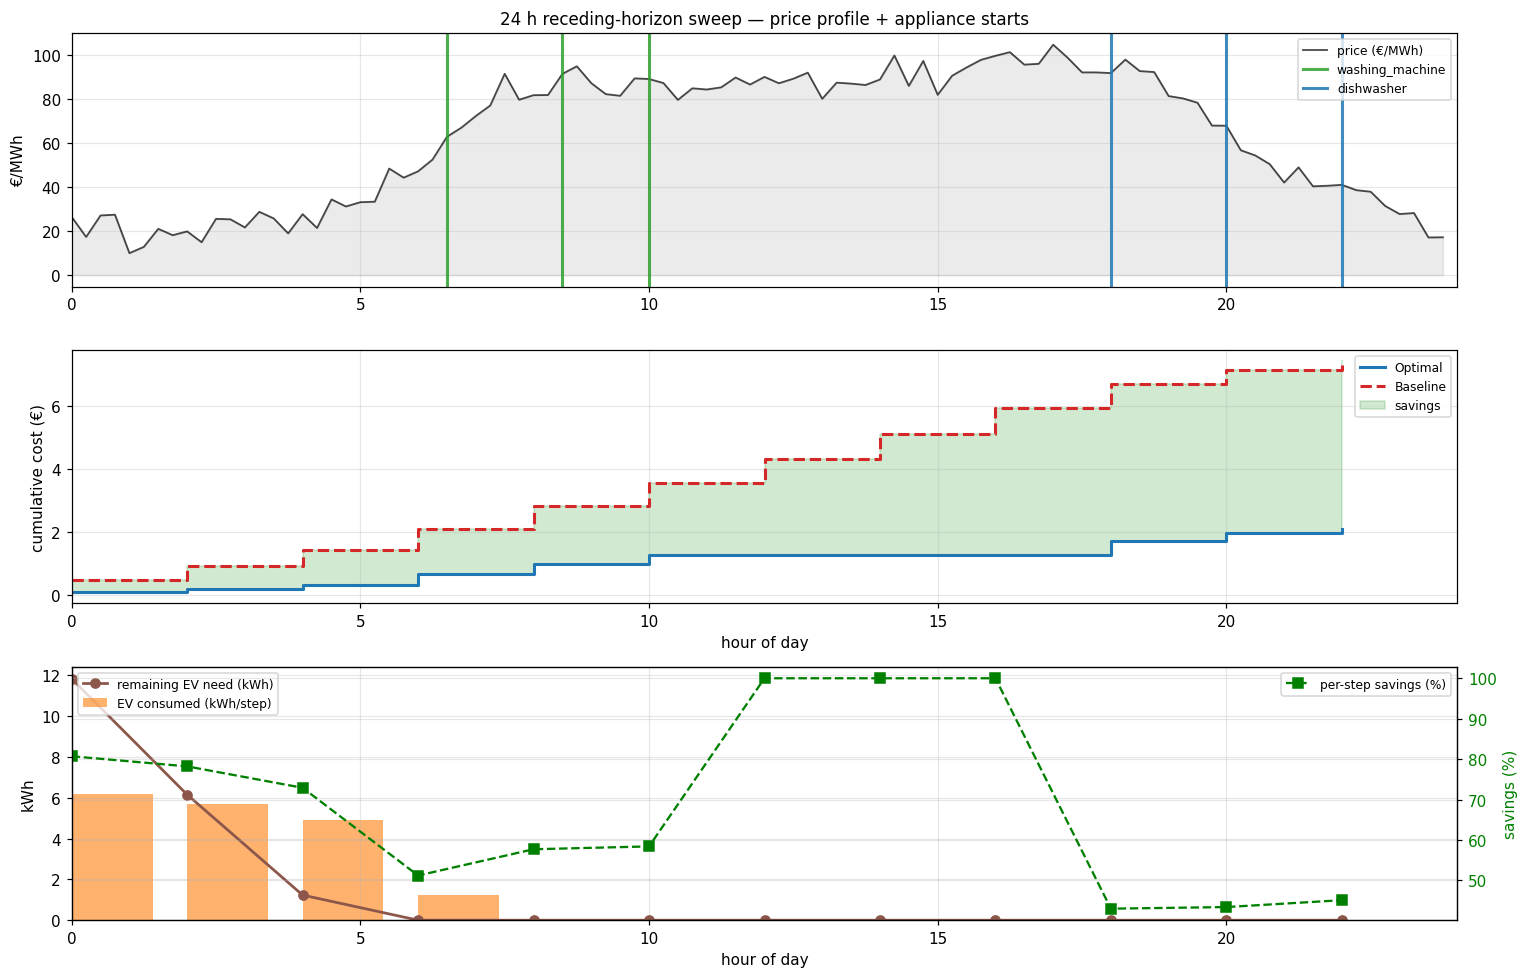

Day total — Optimal: €2.1025  Baseline: €7.4238  Savings: 71.7%


In [8]:
fig_F, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)

# ── Panel 1: price curve + appliance-start markers ───────────────────────────
axes[0].plot(t_day, prices_day, color="k", lw=1.2, alpha=0.7, label="price (€/MWh)")
axes[0].fill_between(t_day, prices_day, alpha=0.08, color="k")

plotted: set = set()
for _, row in df_F.iterrows():
    for app, abs_slot in row["tasks"]:
        color = _PALETTE.get(app, "gray")
        lbl   = app if app not in plotted else None
        axes[0].axvline(abs_slot * SLOT_H, color=color, lw=2, alpha=0.85, label=lbl)
        plotted.add(app)

axes[0].set_ylabel("€/MWh")
axes[0].set_title("24 h receding-horizon sweep — price profile + appliance starts", fontsize=11)
axes[0].legend(fontsize=8, loc="upper right")
axes[0].set_xlim(0, 24)

# ── Panel 2: cumulative optimal vs. baseline cost ────────────────────────────
step_h   = df_F["hour"].values
cum_opt  = np.cumsum(df_F["expected_cost_€"].values)
cum_bas  = np.cumsum(df_F["baseline_cost_€"].values)

axes[1].step(step_h, cum_opt, where="post", color="#1f77b4", lw=2,       label="Optimal")
axes[1].step(step_h, cum_bas, where="post", color="#d62728", lw=2, ls="--", label="Baseline")
axes[1].fill_between(step_h, cum_opt, cum_bas, step="post",
                     where=cum_bas >= cum_opt, alpha=0.18, color="green", label="savings")
axes[1].set_ylabel("cumulative cost (€)")
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 24)
axes[1].set_xlabel("hour of day")

# ── Panel 3: EV state + per-step savings ─────────────────────────────────────
ax3a = axes[2]
ax3b = ax3a.twinx()

bar_w = 1.4
ax3a.bar(step_h, df_F["ev_consumed_kWh"], width=bar_w, align="edge",
         color=_PALETTE["ev_charger"], alpha=0.6, label="EV consumed (kWh/step)")
ax3a.plot(step_h, df_F["remaining_ev_kWh"], "o-", color="#8c564b", lw=1.8,
           label="remaining EV need (kWh)")
ax3a.set_ylabel("kWh")
ax3a.legend(loc="upper left", fontsize=8)
ax3a.set_xlim(0, 24)
ax3a.set_xlabel("hour of day")

ax3b.plot(step_h, df_F["savings_%"], "s--", color="green", lw=1.5,
           label="per-step savings (%)")
ax3b.set_ylabel("savings (%)", color="green")
ax3b.tick_params(axis="y", labelcolor="green")
ax3b.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

total_opt = df_F["expected_cost_€"].sum()
total_bas = df_F["baseline_cost_€"].sum()
print(f"Day total — Optimal: €{total_opt:.4f}  Baseline: €{total_bas:.4f}  "
      f"Savings: {(1 - total_opt / total_bas) * 100:.1f}%")


## Scenario G — Ghost-reservation λ sensitivity

Without the reservation term (`λ = 0`) the MILP **never schedules a new cycle**  
because every cycle strictly increases `C_actual`. The term  
`λ · U_reservation = λ · Σ_a Σ_t s_a[t] · P̂_a(t)` provides the incentive.

We use the **heater** (4 slots, 2 kW) so it has many feasible start positions in the
8-slot horizon (latest start = slot 4). Price valley is at slots 2–4 (€38–45/MWh).

The heater cost at the cheapest start (slot 2) ≈ **€0.084**.  
With onset probability of 0.8 at slot 2, the break-even λ is `0.084 / 0.8 ≈ 0.11`.

Sweep `λ ∈ {0, 0.05, 0.1, 0.15, 0.25, 0.5, 1.0, 2.0}` and observe:
- At which λ does the heater first get scheduled?
- Does it pick the price valley or the onset-peak slot as λ climbs?
- How does `expected_cost` rise with λ?


,lambda,heater_scheduled,heater_start,expected_cost,baseline_cost,savings_%
0,0.00,False,NaN,0.0130,0.464,97.2
1,0.05,False,NaN,0.0130,0.464,97.2
2,0.10,False,NaN,0.0130,0.464,97.2
3,0.15,True,2.0,0.0970,0.464,79.1
4,0.25,True,2.0,0.0970,0.464,79.1
5,0.50,True,3.0,0.1295,0.464,72.1
6,1.00,True,3.0,0.1295,0.464,72.1
7,2.00,True,3.0,0.1295,0.464,72.1


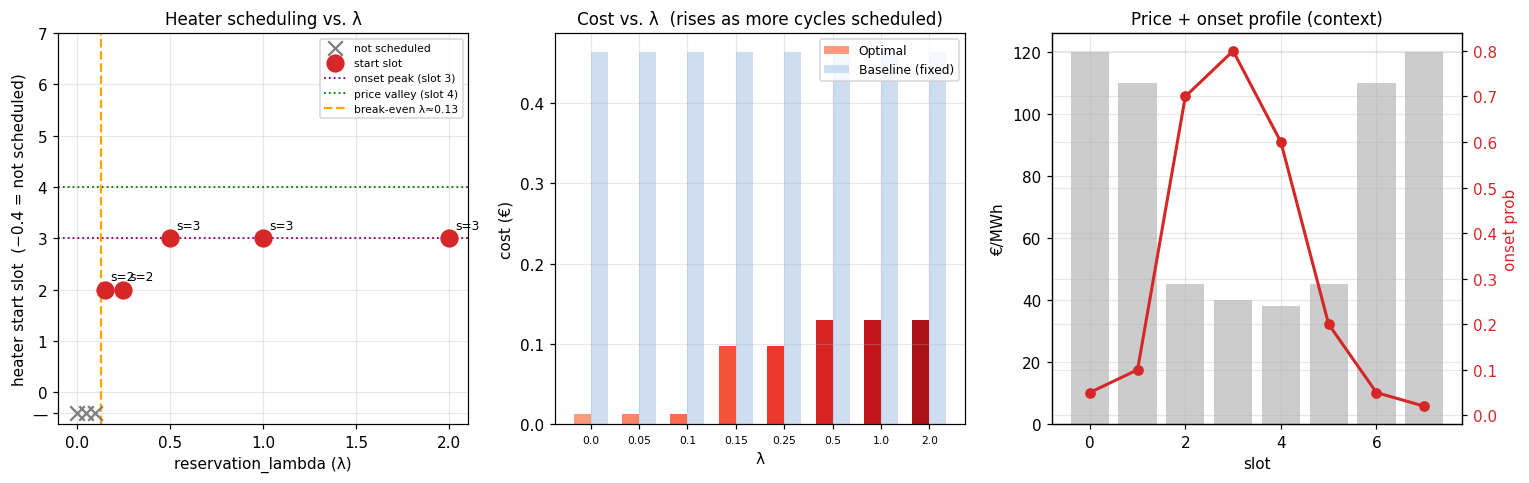

Theoretical break-even λ (heater at slot 2): 0.129
Heater first scheduled at λ = 0.15


In [9]:
prices_G = np.array([120., 110., 45., 40., 38., 45., 110., 120.])
now_G    = _utc(10)    # next 07:00 deadline is 21 h away → C5 vacuous for heater

# Heater onset peaks at the centre of the cheap valley
onset_G = {
    "heater": np.array([0.05, 0.10, 0.70, 0.80, 0.60, 0.20, 0.05, 0.02]),
}

lambdas = [0.0, 0.05, 0.1, 0.15, 0.25, 0.5, 1.0, 2.0]
G_rows = []
for lam in lambdas:
    s = solve_receding_horizon(
        now_G, prices_G.copy(), onset_G,
        remaining_ev_kwh=3.0,
        time_to_deadline_h=21.0,
        horizon_slots=8,
        reservation_lambda=lam,
    )
    ht_start = None
    for task in s.tasks:
        if task.appliance == "heater":
            ht_start = int(task.start_slot)
    G_rows.append({
        "lambda":           lam,
        "heater_scheduled": ht_start is not None,
        "heater_start":     ht_start,
        "expected_cost":    round(s.expected_cost, 4),
        "baseline_cost":    round(s.baseline_cost, 4),
        "savings_%":        round(s.savings() * 100, 1),
    })
df_G = pd.DataFrame(G_rows)
display(df_G)

# ── plot ─────────────────────────────────────────────────────────────────────
fig_G, axes_G = plt.subplots(1, 3, figsize=(14, 4.5))
ax_sched, ax_cost, ax_probe = axes_G

# Left: which slot gets chosen as lambda increases
mask_on  = df_G["heater_scheduled"]
mask_off = ~mask_on

onset_peak_slot  = int(np.argmax(onset_G["heater"]))
price_valley_slot = int(np.argmin(prices_G))

if mask_off.any():
    ax_sched.scatter(df_G.loc[mask_off, "lambda"],
                     [-0.4] * mask_off.sum(),
                     color="gray", s=90, marker="x", zorder=5, label="not scheduled")
if mask_on.any():
    ax_sched.scatter(df_G.loc[mask_on, "lambda"],
                     df_G.loc[mask_on, "heater_start"].astype(float),
                     color=_PALETTE["heater"], s=120, zorder=5, label="start slot")
    for _, row in df_G[mask_on].iterrows():
        ax_sched.annotate(f"s={int(row['heater_start'])}",
                          (row["lambda"], row["heater_start"]),
                          xytext=(4, 6), textcoords="offset points", fontsize=8)

ax_sched.axhline(onset_peak_slot,  color="purple", ls=":", lw=1.2, label=f"onset peak (slot {onset_peak_slot})")
ax_sched.axhline(price_valley_slot, color="green", ls=":", lw=1.2, label=f"price valley (slot {price_valley_slot})")
ax_sched.set_xlabel("reservation_lambda (λ)")
ax_sched.set_ylabel("heater start slot  (−0.4 = not scheduled)")
ax_sched.set_yticks([-0.4] + list(range(8)))
ax_sched.set_yticklabels(["—"] + [str(i) for i in range(8)])
ax_sched.set_title("Heater scheduling vs. λ", fontsize=11)
ax_sched.legend(fontsize=8)

# Middle: cost bars
x_g = np.arange(len(lambdas))
w_g = 0.35
colors_opt = plt.cm.Reds(np.linspace(0.35, 0.85, len(lambdas)))
ax_cost.bar(x_g - w_g/2, df_G["expected_cost"], w_g, color=colors_opt, label="Optimal")
ax_cost.bar(x_g + w_g/2, df_G["baseline_cost"], w_g, color="#aec7e8",
            alpha=0.6, label="Baseline (fixed)")
ax_cost.set_xticks(x_g)
ax_cost.set_xticklabels([f"{l}" for l in lambdas], fontsize=7)
ax_cost.set_xlabel("λ")
ax_cost.set_ylabel("cost (€)")
ax_cost.set_title("Cost vs. λ  (rises as more cycles scheduled)", fontsize=11)
ax_cost.legend(fontsize=8)

# Right: price profile + onset overlay for context
ax_probe.bar(np.arange(8), prices_G, color="k", alpha=0.2, label="price (€/MWh)")
ax_probe_r = ax_probe.twinx()
ax_probe_r.plot(np.arange(8), onset_G["heater"], "o-", color=_PALETTE["heater"],
                lw=2, label="heater onset P̂")
ax_probe.set_xlabel("slot")
ax_probe.set_ylabel("€/MWh", color="k")
ax_probe_r.set_ylabel("onset prob", color=_PALETTE["heater"])
ax_probe_r.tick_params(axis="y", labelcolor=_PALETTE["heater"])
ax_probe.set_title("Price + onset profile (context)", fontsize=11)
# mark break-even threshold
heater_cost_slot2 = APPLIANCES["heater"].rated_kw * APPLIANCES["heater"].cycle_slots * 0.25 * prices_G[2] / 1000
breakeven_lam = heater_cost_slot2 / onset_G["heater"][2]
ax_sched.axvline(breakeven_lam, color="orange", ls="--", lw=1.5,
                  label=f"break-even λ≈{breakeven_lam:.2f}")
ax_sched.legend(fontsize=7)

plt.tight_layout()
plt.show()

print(f"Theoretical break-even λ (heater at slot 2): {breakeven_lam:.3f}")
print(f"Heater first scheduled at λ = {df_G.loc[df_G['heater_scheduled'], 'lambda'].min() if df_G['heater_scheduled'].any() else 'never'}")


## Summary

| Scenario | Feature | Verdict |
|---|---|---|
| A | Price valley shifting | EV + cycles shift into cheapest slots |
| B | EV deadline C2 regime | Tight deadline front-loads charging despite high price |
| C | Power-cap binding (C6) | Stagger is forced when EV + cycle > cap |
| D | Committed task (C6) | EV throttled to `cap − committed_kw` in overlap |
| E | Heater comfort deadline (C5) | Forced slot-0 start despite €250/MWh penalty |
| F | 24 h rolling replan | Cumulative savings compound over the day |
| G | λ sensitivity | λ = 0 ⇒ no cycles; λ > break-even (≈0.13) ⇒ heater scheduled in cheap valley |

All scenarios are **deterministic** — rerunning with the same inputs produces identical results.
